In [1]:
from google.colab import drive
drive.mount("/content/drive")
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/LeNet_NN")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torch.utils.data import SubsetRandomSampler

from MNIST import MNIST

In [3]:
class LeNet(torch.nn.Module):
  def __init__(self):
    super(LeNet, self).__init__()
    # 1 layer: convolution (32x32x1-->28x28x6)
    self.conv_1 = torch.nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2, bias=True)
    # 2 layer: max pooling (28x28x6-->14x14x6)
    self.maxpool_1 = torch.nn.MaxPool2d(kernel_size=2)
    # 3 Layer: convolution (14x14x6-->10x10x16)
    self.conv_2 = torch.nn.Conv2d(in_channels=6, out_channels=16,
    kernel_size=5, stride=1, padding=0, bias=True)
    # 4 layer: max pooling (10x10x16-->5x5x16)
    self.maxpool_2 = torch.nn.MaxPool2d(kernel_size=2)
    # 5 layer: fully connected layer: (5x5x16-->120)
    self.fc_1 = torch.nn.Linear(5*5*16, 120, bias=True)
    # 6 layer: fully connected layer (120-->84)
    self.fc_2 = torch.nn.Linear(120, 84, bias=True)
    # 7 layer: fully connected layer (84 -->10)
    self.fc_3 = torch.nn.Linear(84, 10, bias=True)
  def forward(self, x):
    # 1 layer: conuolution with Relu
    x = torch.nn.functional.relu(self.conv_1(x))
    # 2 layer: max polling
    x = self.maxpool_1(x)
    # 3 layer: conuolution with Relu
    x = torch.nn.functional.relu(self.conv_2(x))
    # 4 layer: max polling
    x = self.maxpool_2(x)
    # flatten 5*5*16
    x = x.view(-1, 5*5*16)
    # layer: fully connected
    x = torch.nn.functional.relu(self.fc_1(x))
    # layer: fully connected
    x = torch.nn.functional.relu(self.fc_2(x))
    x = self.fc_3(x)
    return x

In [4]:
n_epoch = 20
batch_size = 20
eta = 0.01

In [5]:
minst_train = MNIST("train-images.idx3-ubyte","train-labels.idx1-ubyte")
index_list = list(range(len(minst_train)))
sample = SubsetRandomSampler(index_list)
loader = DataLoader(dataset=minst_train, sampler=sample, batch_size=batch_size)

In [6]:
lenet = LeNet()
optimizer = torch.optim.SGD(lenet.parameters(), eta)
criterion = torch.nn.CrossEntropyLoss()

In [7]:
is_GPU = torch.cuda.is_available()
if is_GPU:
  lenet.cuda()

In [8]:
loss_list = []
for epoch in range(n_epoch):
  total_loss = 0
  n_batch = 0

  for images, labels in loader:
    # put the data in GPU
    if is_GPU:
      images = images.cuda()
    labels = labels.type(torch.LongTensor)

    if is_GPU:
      labels = labels.cuda()
    pred_labels = lenet(images)
    loss = criterion(pred_labels, labels)

    total_loss += loss.item()
    n_batch += 1

    loss.backward()

    optimizer.step()
    optimizer.zero_grad()

  average_loss = total_loss / n_batch
  loss_list.append(average_loss)
  print(f"{epoch}:{average_loss}")

0:0.9869595309440047
1:0.13141763955463345
2:0.0903277019012797
3:0.07267661793914158
4:0.06013967084518421
5:0.05163671271817293
6:0.04509486832311571
7:0.040445764463196004
8:0.036650443161845035
9:0.03290848700059481
10:0.029356175366393775
11:0.027222116165973906
12:0.02478817738916526
13:0.022875882831399092
14:0.02126543445732447
15:0.01944427321547725
16:0.01775996530022864
17:0.015938680679406236
18:0.01569683553547005
19:0.014047548434051805


In [9]:
torch.save(lenet.state_dict(), 'nn.pth')

[0.9869595309440047, 0.13141763955463345, 0.0903277019012797, 0.07267661793914158, 0.06013967084518421, 0.05163671271817293, 0.04509486832311571, 0.040445764463196004, 0.036650443161845035, 0.03290848700059481, 0.029356175366393775, 0.027222116165973906, 0.02478817738916526, 0.022875882831399092, 0.02126543445732447, 0.01944427321547725, 0.01775996530022864, 0.015938680679406236, 0.01569683553547005, 0.014047548434051805]


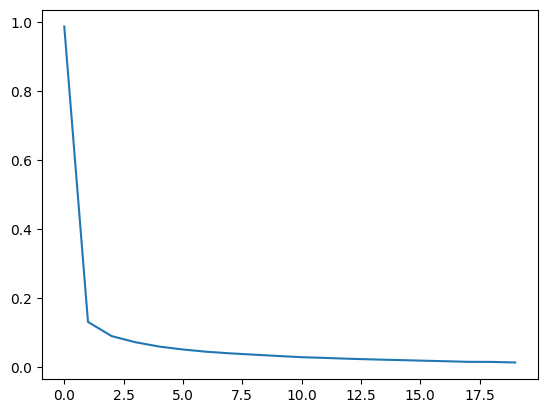

In [10]:
print(f"{loss_list}")
plt.plot(range(len(loss_list)),loss_list)

In [11]:
mnist_test = MNIST("t10k-images.idx3-ubyte", "t10k-labels.idx1-ubyte")

In [15]:
n_test = len(mnist_test)
n_correct = 0
n_wrong = 0
for index in range(n_test):
  image, label = mnist_test[index]
  image = image.reshape(1,image.shape[0],image.shape[1],image.shape[2])
  # image = torch.unsqueeze(image, dim=0)
  if is_GPU:
    image = image.cuda()
  pred_label = lenet(image)
  pred_label = torch.squeeze(pred_label)
  pred_label = torch.argmax(pred_label)
  if label == pred_label:
    n_correct += 1
  else:
    n_wrong += 1

In [17]:
accuracy = n_correct / n_test
print(f'{n_correct}')
print(f'accuracy:{accuracy*100.}%')

9903
accuracy:99.03%
